In [1]:
import os

import matplotlib.pyplot as plt

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["JAX_ENABLE_X64"] = "true"

import numpy as onp
import numpy.typing as npt
import jax
import jax.numpy as jnp
from tqdm import tqdm
from typing import List, Callable, Tuple

from gridops import set_up_grid_axis
from gridops import create_anterpolation_function, make_restriction_operator, \
    make_prolongation_operator, create_interaction_operator

import sys

sys.path.append("/home/florian/PhD/work/code/msm_for_nn/")

from msmfornn.splines.nesting import compute_J_zeroplus


In [2]:
p = 6
order = p - 1

# Construction of grids

In [3]:
length = 10.0
max_gridlevel = 4

grids_all_levels = [None]  # there is no grid at level zero
for l in range(1, max_gridlevel + 1):
    h = length / (2 ** (max_gridlevel - l))
    print(l, h)
    grid = set_up_grid_axis(length=length, h=h, p=p, periodic=False)
    grids_all_levels.append(grid)

1 1.25
2 2.5
3 5.0
4 10.0


In [4]:
grids_all_levels

[None,
 GridAxis1D(periodic=False, length=10.0, h=1.25, n_domain=9, n_total=15, process_raw_indices=<function set_up_grid_axis.<locals>.process_raw_indices_nonperiodic at 0x7fd687d99820>, get_gridindices_and_splinevals=<function set_up_grid_axis.<locals>.get_gridindices_and_splinevals at 0x7fd687d99d30>),
 GridAxis1D(periodic=False, length=10.0, h=2.5, n_domain=5, n_total=11, process_raw_indices=<function set_up_grid_axis.<locals>.process_raw_indices_nonperiodic at 0x7fd687d999d0>, get_gridindices_and_splinevals=<function set_up_grid_axis.<locals>.get_gridindices_and_splinevals at 0x7fd687d5b280>),
 GridAxis1D(periodic=False, length=10.0, h=5.0, n_domain=3, n_total=9, process_raw_indices=<function set_up_grid_axis.<locals>.process_raw_indices_nonperiodic at 0x7fd687db0040>, get_gridindices_and_splinevals=<function set_up_grid_axis.<locals>.get_gridindices_and_splinevals at 0x7fd687d5b430>),
 GridAxis1D(periodic=False, length=10.0, h=10.0, n_domain=2, n_total=8, process_raw_indices=<fun

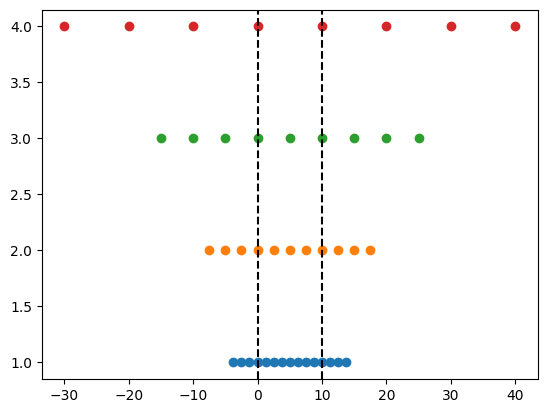

In [5]:
points_all_levels = [None]

fig, ax = plt.subplots()
ax.axvline(0, color='k', linestyle='--')
ax.axvline(length, color='k', linestyle='--')

for l, g in enumerate(grids_all_levels):
    if l == 0:
        continue
    points = (onp.arange(g.n_total) - p // 2) * g.h
    points_all_levels.append(points)
    ax.scatter(points, onp.zeros_like(points) + l)


In [6]:
def shift(m: npt.ArrayLike):
    return m - p // 2


def unshift(m: int):
    return m + p // 2

In [7]:
m_raw = 2
n_raw = shift(onp.arange(len(points_all_levels[1])))

In [8]:
n_raw

array([-3, -2, -1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [9]:
onp.abs(n_raw - 2 * m_raw)

array([7, 6, 5, 4, 3, 2, 1, 0, 1, 2, 3, 4, 5, 6, 7])

In [10]:
onp.abs(n_raw - 2 * m_raw) <= p // 2

array([False, False, False, False,  True,  True,  True,  True,  True,
        True,  True, False, False, False, False])

In [11]:
onp.where(onp.abs(n_raw - 2 * m_raw) <= p // 2)[0]

array([ 4,  5,  6,  7,  8,  9, 10])

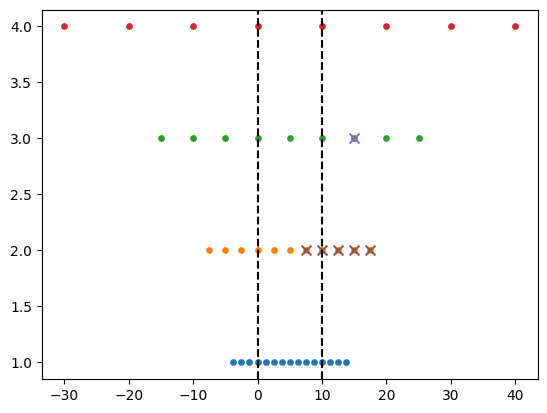

In [12]:
fig, ax = plt.subplots()
ax.axvline(0, color='k', linestyle='--')
ax.axvline(length, color='k', linestyle='--')

for l in range(1, max_gridlevel + 1):
    g = grids_all_levels[l]
    points = points_all_levels[l]
    ax.scatter(points, onp.full_like(points, l), s=15)

l = 3
m_raw = 3
n_raw = shift(onp.arange(len(points_all_levels[l - 1])))
is_in_bounds = onp.where(onp.abs(n_raw - 2 * m_raw) <= p // 2)
n_raw_selected = n_raw[is_in_bounds]

ax.scatter(points_all_levels[l][unshift(m_raw)], l, marker="x", s=50)
ax.scatter(points_all_levels[l - 1][unshift(n_raw_selected)],
           onp.full_like(n_raw_selected, l - 1), marker="x", s=50)

# Restriction

In [13]:
J_zeroplus = compute_J_zeroplus(p)
J = onp.concatenate((J_zeroplus[::-1][:-1], J_zeroplus))
J

array([0.03125, 0.1875 , 0.46875, 0.625  , 0.46875, 0.1875 , 0.03125])

In [14]:
n_particles = 15

rng = onp.random.default_rng(8439293)
xs = rng.uniform(0., length, size=n_particles)
qs = rng.uniform(-1., 1., size=n_particles)

## Compare grid charges computed via restriction with directly computed ones

In [15]:
anterpolation_funcs_all_levels = [None] + [
    jax.jit(create_anterpolation_function(g)) for g in grids_all_levels[1:]]

restriction_funcs_all_levels = [None, None]
for l in range(2, len(grids_all_levels)):
    rf = make_restriction_operator(grid_source=grids_all_levels[l - 1],
                                   grid_target=grids_all_levels[l], J=J)
    rf = jax.jit(rf)
    restriction_funcs_all_levels.append(rf)

In [16]:
# TODO
# gridcharges_direct = [None] + [af(xs, qs)[0] for af in
#                                anterpolation_funcs_all_levels[1:]]
# 
# gridcharges_via_restriction = [None, None]
# for l in range(2, len(grids_all_levels)):
#     rf = restriction_funcs_all_levels[l]
#     gc_lowergrid = gridcharges_direct[l - 1]
#     gc = rf(gc_lowergrid)
#     gridcharges_via_restriction.append(gc)

In [17]:
gridcharges_direct = [None] + [af(xs, qs)[0] for af in
                               anterpolation_funcs_all_levels[1:]]

gridcharges_via_restriction = [None, gridcharges_direct[1]]
for l in range(2, len(grids_all_levels)):
    rf = restriction_funcs_all_levels[l]
    gc_lowergrid = gridcharges_via_restriction[l - 1]
    gc = rf(gc_lowergrid)
    gridcharges_via_restriction.append(gc)

In [18]:
for gc_direct, gc_restrict in zip(gridcharges_direct[2:],
                                  gridcharges_via_restriction[2:]):
    assert jnp.allclose(gc_direct, gc_restrict)

# Test jitting of anterpolation + loop over restriction at all grid levels in single function

In [19]:
def create_anterpolate_and_restrict(grids_all_levels,
                                    J: npt.ArrayLike) -> Callable:
    anterpolate = create_anterpolation_function(grids_all_levels[1])

    restriction_funcs_all_levels = [None, None]
    for lvl in range(2, len(grids_all_levels)):
        rf = make_restriction_operator(grid_source=grids_all_levels[lvl - 1],
                                       grid_target=grids_all_levels[lvl], J=J)
        restriction_funcs_all_levels.append(rf)

    def anterpolate_and_restrict(positions: jax.Array,
                                 charges: jax.Array) -> List:
        gridcharge_level_one, _, _ = anterpolate(positions_1d=positions,
                                                 charges=charges)
        gridcharges_all_levels = [None, gridcharge_level_one]
        for lvl in range(2, len(grids_all_levels)):
            rf = restriction_funcs_all_levels[lvl]
            gc_lowergrid = gridcharges_all_levels[lvl - 1]
            gc = rf(gc_lowergrid)
            gridcharges_all_levels.append(gc)

        return gridcharges_all_levels

    return anterpolate_and_restrict

In [20]:
anterpolate_and_restrict = create_anterpolate_and_restrict(grids_all_levels, J)
jitted_anterpolate_and_restrict = jax.jit(anterpolate_and_restrict)

In [21]:
jitted_anterpolate_and_restrict(xs, qs)

[None,
 Array([ 0.00000000e+00,  7.99206745e-03,  2.38020789e-01,  9.45202429e-01,
         1.23204504e+00,  8.99210087e-01,  6.48432624e-01, -2.65156887e-02,
        -8.73304811e-03,  4.39864870e-01, -4.08880742e-01, -4.94877612e-01,
        -6.66595889e-02, -3.68572921e-04,  0.00000000e+00], dtype=float64),
 Array([ 0.00000000e+00,  8.93666229e-03,  3.32294150e-01,  1.47020880e+00,
         1.62289921e+00,  5.60087309e-01, -4.21757004e-04, -4.50075390e-01,
        -1.37044116e-01, -2.15221957e-03,  0.00000000e+00], dtype=float64),
 Array([ 0.        ,  0.01205982,  0.48772805,  1.9420562 ,  1.30796745,
        -0.19040582, -0.14998688, -0.00468617,  0.        ], dtype=float64),
 Array([ 0.        ,  0.01750272,  0.64116943,  2.01739043,  0.80229814,
        -0.06806231, -0.00556575,  0.        ], dtype=float64)]

# Prolongation

In [22]:
J_rolled = onp.roll(J, (len(J) - 1) // 2 + 1)

ns_raw = jnp.arange(-10, 15)

for m_raw in range(0, 10):
    m_minus_2n = m_raw - 2 * ns_raw
    cond = jnp.abs(m_minus_2n) <= p / 2
    inds_into_J = m_minus_2n[cond]
    print(m_raw, cond.sum(), inds_into_J, J_rolled[inds_into_J])

0 3 [ 2  0 -2] [0.1875 0.625  0.1875]
1 4 [ 3  1 -1 -3] [0.03125 0.46875 0.46875 0.03125]
2 3 [ 2  0 -2] [0.1875 0.625  0.1875]
3 4 [ 3  1 -1 -3] [0.03125 0.46875 0.46875 0.03125]
4 3 [ 2  0 -2] [0.1875 0.625  0.1875]
5 4 [ 3  1 -1 -3] [0.03125 0.46875 0.46875 0.03125]
6 3 [ 2  0 -2] [0.1875 0.625  0.1875]
7 4 [ 3  1 -1 -3] [0.03125 0.46875 0.46875 0.03125]
8 3 [ 2  0 -2] [0.1875 0.625  0.1875]
9 4 [ 3  1 -1 -3] [0.03125 0.46875 0.46875 0.03125]


In [23]:
def find_raw_ns_by_ceil_floor(m_raw):
    if m_raw % 2 == 0:
        start = int(onp.ceil(onp.round(-p / 4, decimals=1)))
        end = int(onp.floor(onp.round(p / 4, decimals=1)))
    else:
        start = int(onp.ceil(onp.round(0.5 - p / 4, decimals=1)))
        end = int(onp.floor(onp.round(0.5 + p / 4, decimals=1)))

    return m_raw // 2 + jnp.arange(start, end + 1), start, end

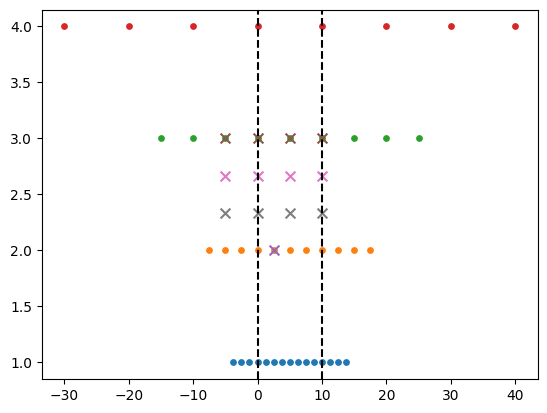

In [24]:
lvl = 2
m_raw = 1

fig, ax = plt.subplots()
ax.axvline(0, color='k', linestyle='--')
ax.axvline(length, color='k', linestyle='--')
for l in range(1, max_gridlevel + 1):
    g = grids_all_levels[l]
    points = points_all_levels[l]
    ax.scatter(points, onp.full_like(points, l), s=15)

ax.scatter(points_all_levels[lvl][unshift(m_raw)], lvl, marker="x", s=50)

# find contributing points by applying comparison
ns_raw = shift(onp.arange(len(points_all_levels[lvl + 1])))
m_minus_2n = m_raw - 2 * ns_raw
cond = jnp.abs(m_minus_2n) <= p // 2
ns_raw_selected = ns_raw[cond]

ax.scatter(points_all_levels[lvl + 1][unshift(ns_raw_selected)],
           onp.full_like(ns_raw_selected, lvl + 1), marker="x", s=50)

# find contributing points by explicit expression
if p % 4 == 0:
    extra = 0
else:
    extra = 1
start = m_raw // 2 - p // 4
end = m_raw // 2 + p // 4
if m_raw % 2 == 0:
    raw_n_range = jnp.arange(start, end + 1)
else:
    raw_n_range = jnp.arange(start + 1 - extra, end + extra + 1)

ax.scatter(points_all_levels[lvl + 1][unshift(raw_n_range)],
           onp.full_like(raw_n_range, lvl + 1 - 0.3333, dtype=float),
           marker="x", s=50)

# find by ceil/floor
raw_ns_by_ceil_floor, start, end = find_raw_ns_by_ceil_floor(m_raw)
ax.scatter(points_all_levels[lvl + 1][unshift(raw_ns_by_ceil_floor)],
           onp.full_like(raw_ns_by_ceil_floor, lvl + 1 - 0.6666, dtype=float),
           marker="x", s=50)

assert onp.array_equal(ns_raw_selected, raw_n_range)
assert onp.array_equal(ns_raw_selected, raw_ns_by_ceil_floor)

In [25]:
lvl = 1

prolongate = make_prolongation_operator(
    grid_source=grids_all_levels[lvl + 1],
    grid_target=grids_all_levels[lvl],
    p=p,
    J_zeroplus=J_zeroplus,
)
jitted_prolongate = jax.jit(prolongate)

In [26]:
prolongate(array_coarse=gridcharges_direct[lvl + 1])

Array([ 0.20589597,  0.48502362,  0.89591813,  1.28547925,  1.4777813 ,
        1.39499253,  1.06920578,  0.65426909,  0.29899397,  0.02036364,
       -0.19795044, -0.30707197, -0.2752927 , -0.17044525, -0.07931314],      dtype=float64)

In [27]:
jitted_prolongate(array_coarse=gridcharges_direct[lvl + 1])

Array([ 0.20589597,  0.48502362,  0.89591813,  1.28547925,  1.4777813 ,
        1.39499253,  1.06920578,  0.65426909,  0.29899397,  0.02036364,
       -0.19795044, -0.30707197, -0.2752927 , -0.17044525, -0.07931314],      dtype=float64)

## Check against explicit matrix multiplication

In [28]:
def get_entry_of_J(idx):
    if onp.abs(idx) > p // 2:
        return 0.
    else:
        return J_zeroplus[abs(idx)]

In [29]:
I_21 = onp.zeros((grids_all_levels[2].n_total, grids_all_levels[1].n_total))
for m in range(I_21.shape[0]):
    for n in range(I_21.shape[1]):
        m_raw = m - p // 2
        n_raw = n - p // 2
        I_21[m, n] = get_entry_of_J(n_raw - 2 * m_raw)

I_12 = I_21.T

In [30]:
I_21

array([[0.03125, 0.     , 0.     , 0.     , 0.     , 0.     , 0.     ,
        0.     , 0.     , 0.     , 0.     , 0.     , 0.     , 0.     ,
        0.     ],
       [0.46875, 0.1875 , 0.03125, 0.     , 0.     , 0.     , 0.     ,
        0.     , 0.     , 0.     , 0.     , 0.     , 0.     , 0.     ,
        0.     ],
       [0.46875, 0.625  , 0.46875, 0.1875 , 0.03125, 0.     , 0.     ,
        0.     , 0.     , 0.     , 0.     , 0.     , 0.     , 0.     ,
        0.     ],
       [0.03125, 0.1875 , 0.46875, 0.625  , 0.46875, 0.1875 , 0.03125,
        0.     , 0.     , 0.     , 0.     , 0.     , 0.     , 0.     ,
        0.     ],
       [0.     , 0.     , 0.03125, 0.1875 , 0.46875, 0.625  , 0.46875,
        0.1875 , 0.03125, 0.     , 0.     , 0.     , 0.     , 0.     ,
        0.     ],
       [0.     , 0.     , 0.     , 0.     , 0.03125, 0.1875 , 0.46875,
        0.625  , 0.46875, 0.1875 , 0.03125, 0.     , 0.     , 0.     ,
        0.     ],
       [0.     , 0.     , 0.     , 0.   

In [31]:
I_12

array([[0.03125, 0.46875, 0.46875, 0.03125, 0.     , 0.     , 0.     ,
        0.     , 0.     , 0.     , 0.     ],
       [0.     , 0.1875 , 0.625  , 0.1875 , 0.     , 0.     , 0.     ,
        0.     , 0.     , 0.     , 0.     ],
       [0.     , 0.03125, 0.46875, 0.46875, 0.03125, 0.     , 0.     ,
        0.     , 0.     , 0.     , 0.     ],
       [0.     , 0.     , 0.1875 , 0.625  , 0.1875 , 0.     , 0.     ,
        0.     , 0.     , 0.     , 0.     ],
       [0.     , 0.     , 0.03125, 0.46875, 0.46875, 0.03125, 0.     ,
        0.     , 0.     , 0.     , 0.     ],
       [0.     , 0.     , 0.     , 0.1875 , 0.625  , 0.1875 , 0.     ,
        0.     , 0.     , 0.     , 0.     ],
       [0.     , 0.     , 0.     , 0.03125, 0.46875, 0.46875, 0.03125,
        0.     , 0.     , 0.     , 0.     ],
       [0.     , 0.     , 0.     , 0.     , 0.1875 , 0.625  , 0.1875 ,
        0.     , 0.     , 0.     , 0.     ],
       [0.     , 0.     , 0.     , 0.     , 0.03125, 0.46875, 0.46875,
 

In [32]:
# Compare restriction operator with explicit matrix multiplication
# (This is arguably redundant for testing the restriction operator, but it shows
# us whether we have correctly set up the I matrix, which we'll use again below)
assert jnp.allclose(I_21 @ gridcharges_direct[1], gridcharges_direct[2])

# Compare prolongation operator with explicit matrix multiplication
assert jnp.allclose(I_12 @ gridcharges_direct[2],
                    prolongate(gridcharges_direct[2]))

# Interaction

In [33]:
kernelstencil = jnp.array([0.5, 1., 2., 4., 2., 1., 0.5])
lvl = 1

apply_interaction = create_interaction_operator(grids_all_levels[lvl],
                                                kernelstencil)
jitted_apply_interaction = jax.jit(apply_interaction)

In [34]:
jitted_apply_interaction(gridcharges_direct[lvl])

Array([ 0.72660614,  2.06923479,  4.54012223,  7.95235983,  9.49419678,
        8.39112628,  6.25496493,  2.9239935 ,  1.23348429,  0.69372512,
       -1.83438322, -2.49546134, -1.44607903, -0.83411145, -0.31483554],      dtype=float64)

## Check against numpy convolution function

In [35]:
assert onp.allclose(
    apply_interaction(gridcharges_direct[lvl]),
    onp.convolve(gridcharges_direct[lvl], kernelstencil, mode="same"),
)

# Full grid potential computation + test jitting

In [36]:
def create_compute_gridpotential_level_one(
    grids, kernelstencils, J: npt.ArrayLike
) -> Callable:
    J_zeroplus = J[len(J) // 2 :]  # TODO: pass J or J_zeroplus?
    p = len(J) - 1  # TODO: How should p be passed/inferred?

    max_gridlevel = len(grids) - 1

    anterpolate = create_anterpolation_function(grids[1])

    restriction_funcs = {}
    for lvl in range(2, max_gridlevel + 1):
        restrict = make_restriction_operator(
            grid_source=grids[lvl - 1], grid_target=grids[lvl], J=J
        )
        restriction_funcs[lvl] = restrict

    prolongation_funcs = {}
    for lvl in range(1, max_gridlevel):
        prolongate = make_prolongation_operator(
            grid_source=grids[lvl + 1],
            grid_target=grids[lvl],
            J_zeroplus=J_zeroplus,
            p=p,
        )
        prolongation_funcs[lvl] = prolongate

    interaction_funcs = {}
    for lvl in range(1, max_gridlevel + 1):
        interact = create_interaction_operator(
            grid=grids[lvl], kernelstencil=kernelstencils[lvl]
        )
        interaction_funcs[lvl] = interact

    def compute_gridpotential_level_one(
        positions: jax.Array, charges: jax.Array
    ) -> Tuple[jax.Array, jax.Array, jax.Array]:
        # Compute lowest-level grid charge from particle positions and charges
        gridcharge_level_one, indices, splinevals = anterpolate(
            positions_1d=positions, charges=charges
        )
        gridcharges_all_levels = {1: gridcharge_level_one}

        # Go up ladder
        for lvl in range(2, max_gridlevel + 1):
            restrict = restriction_funcs[lvl]
            gridcharge_fine = gridcharges_all_levels[lvl - 1]
            gridcharge_coarse = restrict(gridcharge_fine)
            gridcharges_all_levels[lvl] = gridcharge_coarse

        # Apply top-level interaction
        gridcharge_toplevel = gridcharges_all_levels[max_gridlevel]
        interaction_toplevel = interaction_funcs[max_gridlevel]
        gridpotential = interaction_toplevel(gridcharge_toplevel)

        # Go down ladder
        for lvl in range(max_gridlevel - 1, 0, -1):
            gridpotential = interaction_funcs[lvl](
                gridcharges_all_levels[lvl]
            ) + prolongation_funcs[lvl](gridpotential)

        # return gridpotential, indices, splinevals # TODO
        return gridpotential, indices, splinevals, gridcharges_all_levels

    return compute_gridpotential_level_one


In [37]:
# kernelstencils_old_loaded = onp.load("precomputed_kernelstencils_old/kernelstencils.npz")
# 
# stencils = [None]
# for k in kernelstencils_old_loaded.keys():
#     print(k)
#     stencils.append(kernelstencils_old_loaded[k])
#     
# stencils_loaded_symmetric = [None]
# for stncl in stencils[1:]:
#     stncl_symm = jnp.concatenate((stncl[-1:0:-1], stncl))
#     stencils_loaded_symmetric.append(stncl_symm)

In [38]:
# compute_gridpotential_level_one = create_compute_gridpotential_level_one(
#     grids=grids_all_levels,
#     kernelstencils=stencils_loaded_symmetric,
#     J=J,
# )
# jitted_compute_gridpotential_level_one = jax.jit(compute_gridpotential_level_one)

In [39]:
# gridpotential_level_one, indices, splinevals = compute_gridpotential_level_one(positions, charges)

In [40]:
# jitted_compute_gridpotential_level_one(positions, charges)

# Interpolation

In [41]:
# 0.5 * (gridpotential_level_one[indices] * splinevals).sum()

In [42]:
sys.path.append("/home/florian/PhD/work/code/msm_for_nn/")

from msmjax.kernels import SofteningFunctionOneOverR, split_one_over_r_kernel
from msmfornn.gridtools import construct_grids_all_levels
from msmfornn.splines.coefficients import compute_coeffs_withtruncation
from msmfornn.grid_to_grid_mapping import compute_kernel_stencils_all_gridlevels

In [43]:
level_one_gridspacing = 1.25
alpha = 3
level_zero_cutoff = alpha * level_one_gridspacing

params_oldmsm = {
    "min_pos": onp.array([0.]),
    "max_pos": onp.array([length]),
    "level_one_gridspacing": grids_all_levels[1].h,
    "level_zero_cutoff": level_zero_cutoff,
    "max_gridlevel": max_gridlevel,
    "p": p,
    "mu": 3
}

grids_oldmsm = construct_grids_all_levels(
    min_pos=params_oldmsm["min_pos"],
    max_pos=params_oldmsm["max_pos"],
    p=params_oldmsm["p"],
    level_one_gridspacing=params_oldmsm["level_one_gridspacing"],
    max_gridlevel=params_oldmsm["max_gridlevel"],
)
partial_kernels = split_one_over_r_kernel(
    max_level=max_gridlevel,
    level_zero_cutoff=level_zero_cutoff,
    softening_function=SofteningFunctionOneOverR(p),
)
omega, _ = compute_coeffs_withtruncation(p=params_oldmsm["p"], mu=params_oldmsm["mu"])
omega_zeroplus = omega[len(omega) // 2 : ]

kernelstencils_old = compute_kernel_stencils_all_gridlevels(
    kernelfunctions=partial_kernels,
    grids=grids_oldmsm,
    level_zero_cutoff=level_zero_cutoff,
    omega_zeroplus=omega_zeroplus,
)
kernelstencils_old_symmetric = [None]
for stncl in kernelstencils_old[1:]:
    stncl_symm = jnp.concatenate((stncl[-1:0:-1], stncl))
    kernelstencils_old_symmetric.append(stncl_symm)

In [44]:
compute_gridpotential_level_one = create_compute_gridpotential_level_one(
    grids=grids_all_levels,
    kernelstencils=kernelstencils_old_symmetric,
    J=J,
)
jitted_compute_gridpotential_level_one = jax.jit(compute_gridpotential_level_one)

In [45]:
# gridpotential_level_one, indices, splinevals = compute_gridpotential_level_one(positions=xs, charges=qs)

In [46]:
gridpotential_level_one, indices, splinevals, gcs_debug = compute_gridpotential_level_one(positions=xs, charges=qs)

In [47]:
assert jnp.allclose(gcs_debug[max_gridlevel], gridcharges_direct[max_gridlevel])

In [48]:
# gridpotential_level_one, indices, splinevals = jitted_compute_gridpotential_level_one(positions=xs, charges=qs)
# 
# 0.5 * (gridpotential_level_one[indices] * splinevals).sum()

In [49]:
gridpotential_level_one, indices, splinevals, gcs_debug = jitted_compute_gridpotential_level_one(positions=xs, charges=qs)

0.5 * (gridpotential_level_one[indices] * splinevals).sum()

Array(9.06082334, dtype=float64)

In [50]:
def sum_of_kernels_level_one_and_above(r):
    return jnp.sum(jnp.asarray([k(r) for k in partial_kernels[1:]]))


energy = 0.
for i in range(len(xs)):
    for j in range(0, len(xs)):
        r_ij = jnp.linalg.norm(xs[i] - xs[j])
        energy += qs[i] * qs[j] * sum_of_kernels_level_one_and_above(r_ij)
        
energy *= 0.5

In [51]:
energy

Array(4.58216437, dtype=float64)